<a href="https://colab.research.google.com/github/Abu1820/House-Price-Prediction-ML/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

House_Price_Prediction

1. Import Libraries

In [44]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

2. Load Dataset

In [45]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [46]:
df = pd.read_csv('/content/drive/MyDrive/Housing.csv')

3. Understand the Dataset

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [48]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [49]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


4. Data Cleaning

In [50]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [51]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
540,False
541,False
542,False
543,False


5. Convert Text to Numbers

In [52]:
list1 = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']

In [53]:
df[list1] = df[list1].replace({'yes' : 1, 'no' : 0})

/tmp/ipykernel_471/287047901.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[list1] = df[list1].replace({'yes' : 1, 'no' : 0})


In [54]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [55]:
df['furnishingstatus'].unique() # nunique() -> gives number of unique objects

array(['furnished', 'semi-furnished', 'unfurnished'], dtype=object)

In [56]:
df['furnishingstatus'] = df['furnishingstatus'].replace({'furnished' : 0 ,'semi-furnished' : 1 , 'unfurnished' : 2})

/tmp/ipykernel_471/3858839684.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['furnishingstatus'] = df['furnishingstatus'].replace({'furnished' : 0 ,'semi-furnished' : 1 , 'unfurnished' : 2})


In [57]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


5. Standardization(Data Preprocessing)

In [58]:
# from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [59]:
df[['area']] = scaler.fit_transform(df[['area']])

In [60]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,1.046726,4,2,3,1,0,0,0,1,2,1,0
1,12250000,1.757010,4,4,4,1,0,0,0,1,3,0,0
2,12250000,2.218232,3,2,2,1,0,1,0,0,2,1,1
3,12215000,1.083624,4,2,2,1,0,1,0,1,3,1,0
4,11410000,1.046726,4,1,2,1,1,1,0,1,2,0,0


In [61]:
df.dtypes

,0
price,int64
area,float64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,int64
guestroom,int64
basement,int64
hotwaterheating,int64
airconditioning,int64


6. Select Features (X)




In [62]:
X = df.drop('price', axis = 1)

In [63]:
X.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,1.046726,4,2,3,1,0,0,0,1,2,1,0
1,1.757010,4,4,4,1,0,0,0,1,3,0,0
2,2.218232,3,2,2,1,0,1,0,0,2,1,1
3,1.083624,4,2,2,1,0,1,0,1,3,1,0
4,1.046726,4,1,2,1,1,1,0,1,2,0,0


7. Select Target (y)

In [64]:
y = df['price']

In [65]:
y.head()

,price
0,13300000
1,12250000
2,12250000
3,12215000
4,11410000


8. Split the Dataset

In [66]:
# from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,random_state=42
)

In [67]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(436, 12)
(109, 12)
(436,)
(109,)


9. Create Model

In [68]:
# from sklearn.linear_model import LinearRegression
model = LinearRegression()

10. Train Model

In [69]:
model.fit(X_train,y_train)

LinearRegression()

11. Predict Prices

In [70]:
y_pred = model.predict(X_test)

12. Check Error

In [71]:
# from sklearn.metrics import mean_absolute_error
print("Mean Absolute Error : ",mean_absolute_error(y_test,y_pred))

Mean Absolute Error :  979679.6912959907


13. Checks Accuracy

In [72]:
# from sklearn.metrics import r2_score
print("R2 score : ",r2_score(y_test,y_pred))

R2 score :  0.6494754192267794


14. Visualization (Actual vs Predicted)

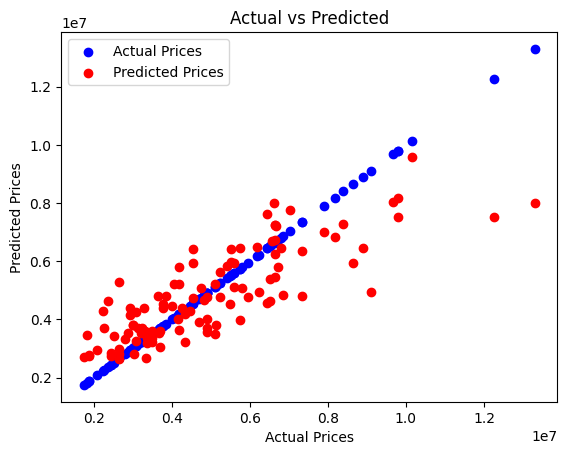

In [73]:
plt.scatter(y_test, y_test, color='blue', label='Actual Prices')   # y_test
plt.scatter(y_test, y_pred, color='red', label='Predicted Prices') # y_pred
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.legend()
plt.show()